In [1]:
import pandas as pd

# Load your dataset
df = pd.read_csv("Uber-Jan-Feb-FOIL (1).csv")

# View first rows
df.head()


,dispatching_base_number,date,active_vehicles,trips
0,B02512,1/1/2015,190,1132
1,B02765,1/1/2015,225,1765
2,B02764,1/1/2015,3427,29421
3,B02682,1/1/2015,945,7679
4,B02617,1/1/2015,1228,9537


In [3]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Create time-based features
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week  # Changed from .week to .isocalendar().week

# Check
df.head()

,dispatching_base_number,date,active_vehicles,trips,day,weekday,month,week
0,B02512,2015-01-01,190,1132,1,Thursday,1,1
1,B02765,2015-01-01,225,1765,1,Thursday,1,1
2,B02764,2015-01-01,3427,29421,1,Thursday,1,1
3,B02682,2015-01-01,945,7679,1,Thursday,1,1
4,B02617,2015-01-01,1228,9537,1,Thursday,1,1


In [4]:
daily = df.groupby('date').agg({
    'trips':'sum',
    'active_vehicles':'sum'
}).reset_index()

daily.head()


,date,trips,active_vehicles
0,2015-01-01,56437,6885
1,2015-01-02,39189,6330
2,2015-01-03,58449,6510
3,2015-01-04,40798,5838
4,2015-01-05,42752,6884


In [5]:
daily['day'] = daily['date'].dt.day
daily['weekday'] = daily['date'].dt.day_name()
daily['month'] = daily['date'].dt.month
daily['week'] = daily['date'].dt.isocalendar().week

daily.head()


,date,trips,active_vehicles,day,weekday,month,week
0,2015-01-01,56437,6885,1,Thursday,1,1
1,2015-01-02,39189,6330,2,Friday,1,1
2,2015-01-03,58449,6510,3,Saturday,1,1
3,2015-01-04,40798,5838,4,Sunday,1,1
4,2015-01-05,42752,6884,5,Monday,1,2


In [8]:
pd.set_option('display.max_rows', None)
daily


,date,trips,active_vehicles,day,weekday,month,week
0,2015-01-01,56437,6885,1,Thursday,1,1
1,2015-01-02,39189,6330,2,Friday,1,1
2,2015-01-03,58449,6510,3,Saturday,1,1
3,2015-01-04,40798,5838,4,Sunday,1,1
4,2015-01-05,42752,6884,5,Monday,1,2
5,2015-01-06,52426,7216,6,Tuesday,1,2
6,2015-01-07,62102,7444,7,Wednesday,1,2
7,2015-01-08,71413,7999,8,Thursday,1,2
8,2015-01-09,70296,7989,9,Friday,1,2
9,2015-01-10,78484,7346,10,Saturday,1,2


In [9]:
print("Raw rows:", len(df))
print("Daily rows:", len(daily))


Raw rows: 354
Daily rows: 59


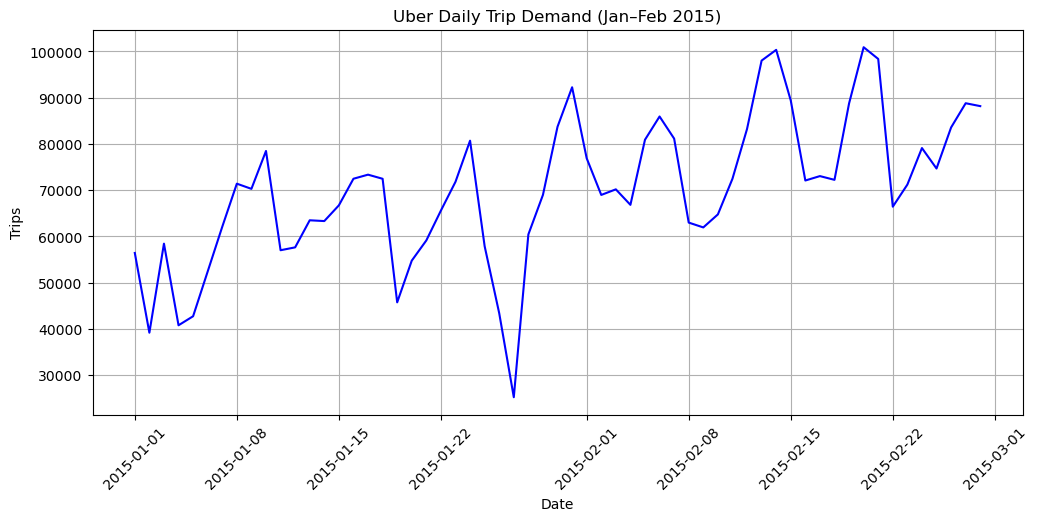

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily['date'], daily['trips'], color='blue')
plt.title("Uber Daily Trip Demand (Jan–Feb 2015)")
plt.xlabel("Date")
plt.ylabel("Trips")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [11]:
# Top 10 busiest days
daily.sort_values(by='trips', ascending=False).head(10)


,date,trips,active_vehicles,day,weekday,month,week
50,2015-02-20,100915,9649,20,Friday,2,8
44,2015-02-14,100345,8973,14,Saturday,2,7
51,2015-02-21,98380,8765,21,Saturday,2,8
43,2015-02-13,98024,9604,13,Friday,2,7
30,2015-01-31,92257,8223,31,Saturday,1,5
45,2015-02-15,89401,7939,15,Sunday,2,7
57,2015-02-27,88806,9486,27,Friday,2,9
49,2015-02-19,88757,9030,19,Thursday,2,8
58,2015-02-28,88181,8681,28,Saturday,2,9
36,2015-02-06,85940,8937,6,Friday,2,6


In [12]:
# Average trips by weekday
daily.groupby('weekday')['trips'].mean().sort_values(ascending=False)


weekday
Saturday     83480.555556
Friday       79021.333333
Thursday     73960.777778
Wednesday    66407.875000
Sunday       65492.875000
Tuesday      60382.625000
Monday       57974.875000
Name: trips, dtype: float64

In [13]:

daily = daily.sort_values('date')


daily['target'] = daily['trips'].shift(-1)

ml_data = daily.dropna()

X = ml_data[['trips','active_vehicles','day','month','week']]
y = ml_data['target']

X.head(), y.head()


(   trips  active_vehicles  day  month  week
 0  56437             6885    1      1     1
 1  39189             6330    2      1     1
 2  58449             6510    3      1     1
 3  40798             5838    4      1     1
 4  42752             6884    5      1     2,
 0    39189.0
 1    58449.0
 2    40798.0
 3    42752.0
 4    52426.0
 Name: target, dtype: float64)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, predictions)
print("Model MAPE:", mape)


Model MAPE: 0.1021870774209624


In [15]:
# Create a dataframe for predictions
test_data = X_test.copy()
test_data['actual_trips'] = y_test.values
test_data['predicted_trips'] = predictions

test_data.head()


,trips,active_vehicles,day,month,week,actual_trips,predicted_trips
46,72098,7551,16,2,8,73051.0,68005.535
47,73051,8403,17,2,8,72243.0,83569.085
48,72243,8442,18,2,8,88757.0,83511.085
49,88757,9030,19,2,8,100915.0,88772.505
50,100915,9649,20,2,8,98380.0,96965.615


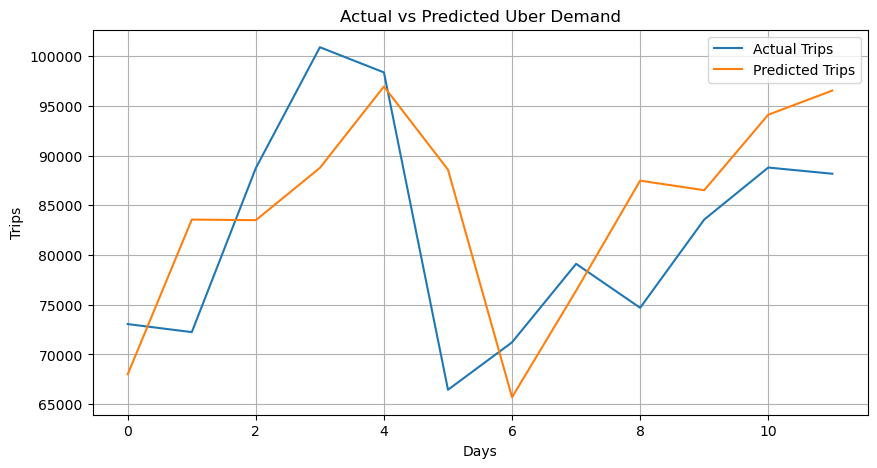

In [16]:
plt.figure(figsize=(10,5))
plt.plot(test_data['actual_trips'].values, label='Actual Trips')
plt.plot(test_data['predicted_trips'].values, label='Predicted Trips')
plt.title("Actual vs Predicted Uber Demand")
plt.xlabel("Days")
plt.ylabel("Trips")
plt.legend()
plt.grid(True)
plt.show()


In [17]:
daily.to_excel("uber_daily_demand.xlsx", index=False)

test_data.to_excel("uber_predictions.xlsx", index=False)

print("Files exported successfully!")


Files exported successfully!
